In [44]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models.train_model.train_model import *
from src.models.filter_data.feature_adder import Feature_adder

In [45]:
import plotly.express as px
def show(df_m1,save=False,parm=None,ass=""):

    '''
    fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                    title='Generation over Time by Batch Interval',
                    labels={'generation': 'Generation', 'datetime': 'Time'},
                    hover_data=['datetime', 'generation', 'temperature','interval_id'])
    
    if save : fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}.html")
    else : fig.show()
    '''
    
    fig = px.scatter(df_m1, x="temperature", y='generation', color='is_good_peak',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation'},
                hover_data=['generation', 'temperature'])
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}_s.html")
    else: fig.show()
    

In [46]:
name_codes = []
if __name__ == "__main__":
    goodness_to_select = 5
    save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

    df_r_selected = select_data(goodness_to_select)
    df_f_selected = select_features(df_r_selected)

    ds_n_c = Data_selector(df_f_selected)
    ds_n_c.df = ds_n_c.df.dropna()
    power_plants = ds_n_c.df[['name', 'code']].drop_duplicates()
    train_errors = []
    test_errors = []
    for row in power_plants.itertuples():
        name, code = row.name, row.code
        #logger.info(f"Train and test data related to {name}_{code}:")

        df_n_c = ds_n_c.filter_name_code(name, code)

        fs_n_c = Feature_selector(df_n_c, "generation")
        fs_n_c.filter_features(features_to_drop=["name", "code"])
        X, y = fs_n_c.get_X_and_y()
        # X = make_onehot(X)

        train_error, test_error = train_and_test_model(X, y, save_model_folder,name,code)
        #logger.info(f"Train rmse error: {train_error:.3f}%, Test rmse error: {test_error:.3f}%")
        name_codes.append((name,code))
        train_errors.append(train_error)
        test_errors.append(test_error)
        

    print(np.mean(train_errors))
    print(np.mean(test_errors))

2025-10-15 16:52:15 - src.models.train_model.train_model - INFO - Rows with goodness=5 have been selected
2025-10-15 16:52:15 - src.models.train_model.train_model - INFO - Features have been selected successfully


2.0968983036289277
5.02166290226513


In [47]:
name_codes = np.array(name_codes)
train_error = np.array(train_errors)
test_error = np.array(test_errors)

In [48]:
name_codes[train_error>4]

array([['سیکل ترکیبی ارومیه', 'G13'],
       ['سیکل ترکیبی شیروان', 'G11'],
       ['سیکل ترکیبی شیروان', 'G12'],
       ['سیکل ترکیبی شیروان', 'G13'],
       ['سیکل ترکیبی شیروان', 'G14'],
       ['سیکل ترکیبی شیروان', 'G15']], dtype='<U21')

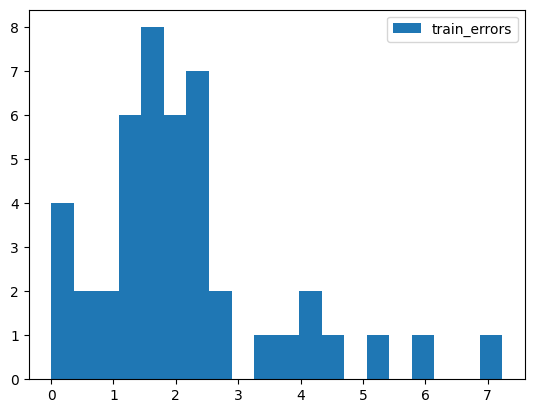

In [49]:
import matplotlib.pyplot as plt
plt.hist(train_errors,label="train_errors",bins=20)
#plt.hist(test_errors,label="test_errors")
plt.legend()
plt.show()

In [52]:
from joblib import load
import os

name ="سیکل ترکیبی ارومیه"
code = "G11"
folder_path = os.path.join(project_root, "src", "models", "fitted_models")
model = load(f"{folder_path}/model_{name}_{code}.joblib")
df_r_selected = select_data(goodness=3)
#df_f_selected = select_features(df_r_selected)
#ds_n_c = Data_selector(df_f_selected)
ds_n_c = Data_selector(df_r_selected)

2025-10-15 16:52:40 - src.models.train_model.train_model - INFO - Rows with goodness=3 have been selected


In [53]:
df_n_c = ds_n_c.filter_name_code(name, code)
show(df_n_c)

In [35]:
df_n_c = ds_n_c.filter_name_code(name, code)
fs_n_c = Feature_selector(df_n_c, "generation")
fs_n_c.filter_features(features_to_drop=["name", "code"])
X, y = fs_n_c.get_X_and_y()

In [ ]:
y_pred = model.predict(X)
res = (y_pred - y)/y
_=plt.hist(res,bins=30)

In [30]:
show(df_n_c)